### [Future Stock Price Movements with Historical & Implied Volatility](https://medium.datadriveninvestor.com/future-stock-price-movements-with-historical-implied-volatility-using-python-and-monte-carlost-740349dcf35f)

---



In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if not IN_COLAB:
  !pip install -q --no-deps pandas numpy matplotlib seaborn plotly scipy
  !pip install -q --no-deps yfinance pandas-datareader pandas-ta

import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta

import numpy as np
import pandas as pd

import yfinance as yf

from scipy.stats import norm

import matplotlib.pyplot as plt

%autosave 10

Autosaving every 10 seconds


In [2]:
# Define thresholds
upper_threshold = 650
lower_threshold = 540

# Download historical data for ASML.AS
symbol = "ASML.AS"
start_date = "2020-01-01"
end_date = "2023-12-31"
df = yf.download(symbol, start=start_date, end=end_date, progress=False, multi_level_index=False)
display(df.sample(15))

,Close,High,Low,Open,Volume
Date,,,,,
2021-04-06,508.960632,518.408828,506.861027,515.354862,947731
2020-04-08,244.050095,244.050095,236.813731,239.320442,1127787
2020-04-03,215.814056,218.982930,210.374956,215.293806,1301604
2023-02-21,581.071594,587.691262,573.867802,584.089366,488917
2020-06-01,278.457153,283.305679,275.510008,283.305679,642918
2023-09-22,543.309082,548.495558,534.795401,537.241858,400841
2020-11-30,347.244171,353.447516,346.146662,347.148729,1347554
2022-06-21,453.897827,455.782034,443.945423,446.554291,676963
2021-09-27,686.146423,715.338033,684.423593,713.040965,751672


In [3]:
display(yf.ticker.Ticker(symbol).history_metadata)

{'currency': 'EUR',
 'symbol': 'ASML.AS',
 'exchangeName': 'AMS',
 'fullExchangeName': 'Amsterdam',
 'instrumentType': 'EQUITY',
 'firstTradeDate': 900918000,
 'regularMarketTime': 1774360826,
 'hasPrePostMarketData': False,
 'gmtoffset': 3600,
 'timezone': 'CET',
 'exchangeTimezoneName': 'Europe/Amsterdam',
 'regularMarketPrice': 1191.6,
 'fiftyTwoWeekHigh': 1312.8,
 'fiftyTwoWeekLow': 508.4,
 'regularMarketDayHigh': 1196.4,
 'regularMarketDayLow': 1161.8,
 'regularMarketVolume': 372707,
 'longName': 'ASML Holding N.V.',
 'shortName': 'ASML HOLDING',
 'chartPreviousClose': 1191.0,
 'previousClose': 1175.4,
 'scale': 3,
 'priceHint': 2,
 'currentTradingPeriod': {'pre': {'timezone': 'CET',
   'end': 1774339200,
   'start': 1774339200,
   'gmtoffset': 3600},
  'regular': {'timezone': 'CET',
   'end': 1774369800,
   'start': 1774339200,
   'gmtoffset': 3600},
  'post': {'timezone': 'CET',
   'end': 1774369800,
   'start': 1774369800,
   'gmtoffset': 3600}},
 'tradingPeriods':             

In [4]:
# Calculate daily returns
log_returns = np.log(df['Close'] / df['Close'].shift(1))
display(log_returns.sample(15))

,Close
Date,
2021-10-14,0.037781
2023-01-31,-0.001327
2021-01-15,-0.026043
2020-12-28,0.008477
2021-05-28,0.015142
2020-07-24,-0.050184
2021-10-20,-0.038659
2022-01-26,0.025053
2021-03-17,-0.004976


In [5]:
# Monte Carlo simulation parameters
days_to_forecast = 20
num_simulations = 10000
dt = 1  # 1 trading day

In [6]:
# Volatility for BSM
volatility_bsm = 0.29  # Assuming 29% annualized volatility
print(f"BMS Implied Volatility: {volatility_bsm}")

BMS Implied Volatility: 0.29


BMS Implied Volatility:  0.29
Historical Volatility:  0.023459569492108603


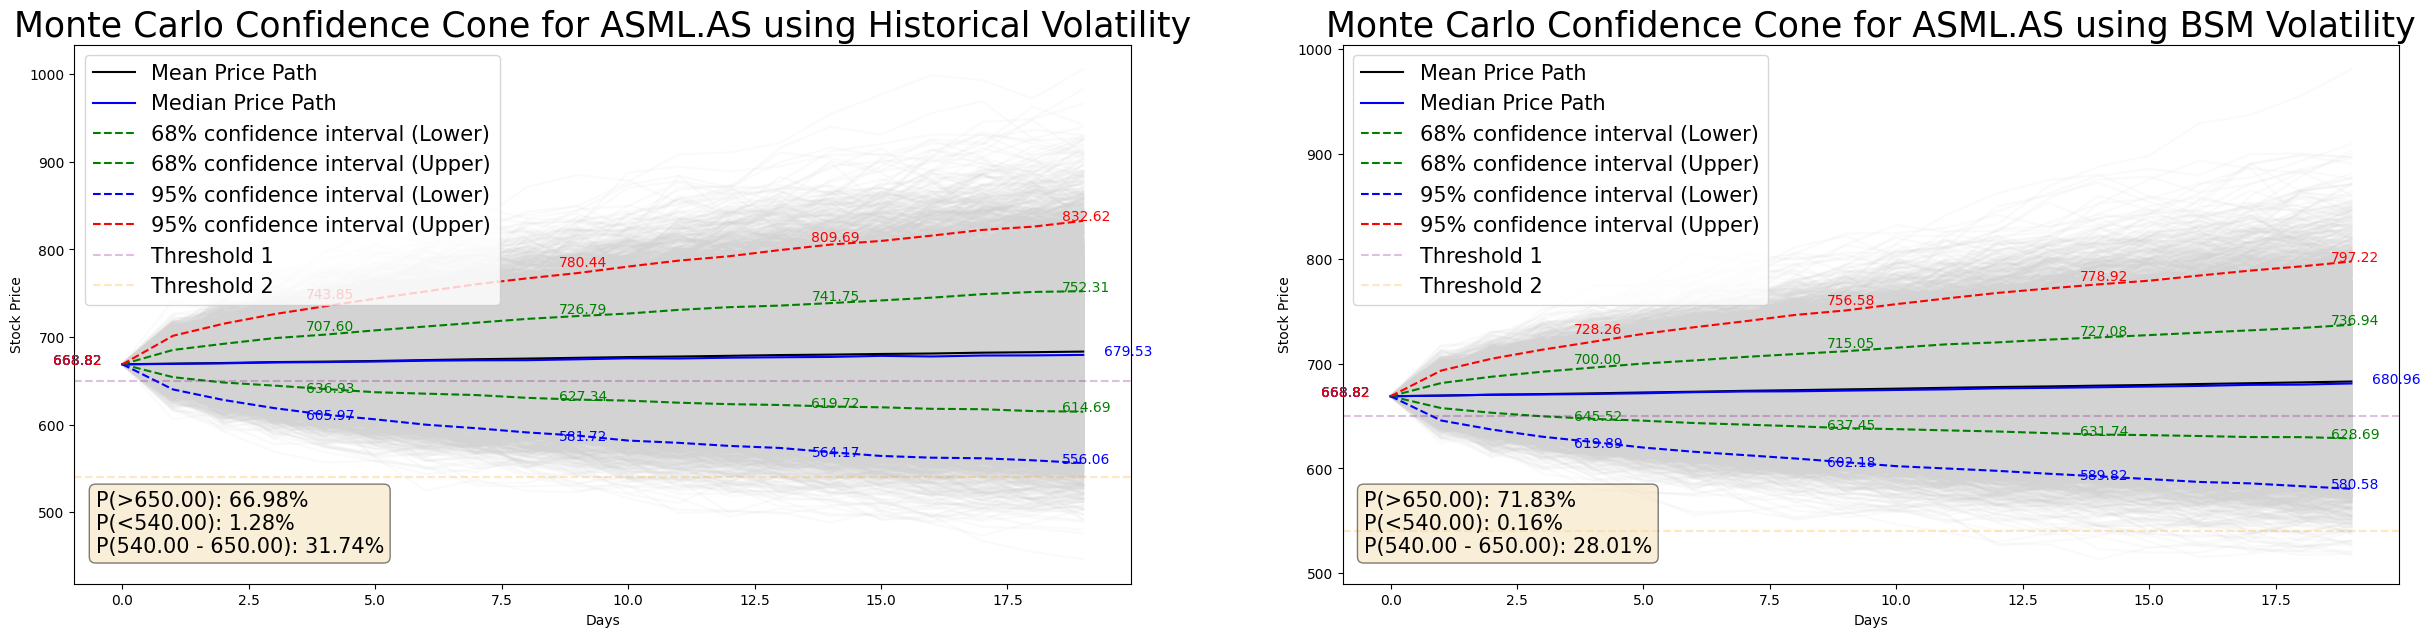

In [7]:
# Download historical data for ASML.AS
symbol = "ASML.AS"
start_date = "2020-01-01"
end_date = "2023-12-30"
df = yf.download(symbol, start=start_date, end=end_date, progress=False, multi_level_index=False)

# Calculate daily returns
log_returns = np.log(df['Close'] / df['Close'].shift(1))

# Monte Carlo simulation parameters
days_to_forecast = 20
num_simulations = 10000
dt = 1  # 1 trading day

# Define thresholds
threshold2 = 540 #144 #116
threshold1 = 650 #162 #128

# Volatility for BSM
volatility_bsm = 0.29 # Assuming 29% annualized volatility

print("BMS Implied Volatility: ", volatility_bsm)

# Run Monte Carlo simulations
def run_simulation(volatility, dt, annualized=False):
    simulated_prices = np.zeros((days_to_forecast, num_simulations))
    simulated_prices[0] = df['Close'][-1]

    # Adjust volatility for annualized estimates
    if annualized:
        volatility = volatility / np.sqrt(252)

    for t in range(1, days_to_forecast):
        random_walk = np.random.normal(loc=log_returns.mean() * dt,
                                       scale=volatility * np.sqrt(dt),
                                       size=num_simulations)
        simulated_prices[t] = simulated_prices[t - 1] * np.exp(random_walk)
    return simulated_prices

simulated_prices_historical = run_simulation(log_returns.std(), dt)
simulated_prices_bsm = run_simulation(volatility_bsm, dt, annualized=True)

print("Historical Volatility: ", log_returns.std())

# Plot the results
fig, axs = plt.subplots(1, 2, figsize=(30, 7))

for simulated_prices, ax, title in zip([simulated_prices_historical, simulated_prices_bsm], axs, ['Historical Volatility', 'BSM Volatility']):
    mean_price_path = np.mean(simulated_prices, axis=1)
    median_price_path = np.median(simulated_prices, axis=1)
    lower_bound_68 = np.percentile(simulated_prices, 16, axis=1)
    upper_bound_68 = np.percentile(simulated_prices, 84, axis=1)
    lower_bound_95 = np.percentile(simulated_prices, 2.5, axis=1)
    upper_bound_95 = np.percentile(simulated_prices, 97.5, axis=1)

    # Define thresholds
    threshold1 = threshold1
    threshold2 = threshold2

    ax.plot(simulated_prices, color='lightgray', alpha=0.1)
    ax.plot(mean_price_path, color='black', label='Mean Price Path')
    ax.plot(median_price_path, color='blue', label='Median Price Path')
    ax.plot(lower_bound_68, color='green', linestyle='--', label='68% confidence interval (Lower)')
    ax.plot(upper_bound_68, color='green', linestyle='--', label='68% confidence interval (Upper)')
    ax.plot(lower_bound_95, color='blue', linestyle='--', label='95% confidence interval (Lower)')
    ax.plot(upper_bound_95, color='red', linestyle='--', label='95% confidence interval (Upper)')

    ax.axhline(y=threshold1, color='purple', linestyle='--', alpha=0.25, label='Threshold 1')
    ax.axhline(y=threshold2, color='orange', linestyle='--', alpha=0.25, label='Threshold 2')

    # Plot settings
    ax.set_xlabel('Days')
    ax.set_ylabel('Stock Price')
    ax.set_title(f'Monte Carlo Confidence Cone for {symbol} using {title}', fontsize = 25)
    ax.legend(fontsize = 15)

    # Add price estimates every 5 days
    for day in range(0, days_to_forecast, 5):
        ax.annotate(f'{lower_bound_68[day]:.2f}', xy=(day, lower_bound_68[day]), xycoords='data',
                    xytext=(-50, 0), textcoords='offset points', color='green')
        ax.annotate(f'{upper_bound_68[day]:.2f}', xy=(day, upper_bound_68[day]), xycoords='data',
                    xytext=(-50, 0), textcoords='offset points', color='green')
        ax.annotate(f'{lower_bound_95[day]:.2f}', xy=(day, lower_bound_95[day]), xycoords='data',
                    xytext=(-50, 0), textcoords='offset points', color='blue')
        ax.annotate(f'{upper_bound_95[day]:.2f}', xy=(day, upper_bound_95[day]), xycoords='data',
                    xytext=(-50, 0), textcoords='offset points', color='red')

    # Add probability annotations
    above_threshold1_prob = (simulated_prices[-1] > threshold1).sum() / num_simulations
    below_threshold2_prob = (simulated_prices[-1] < threshold2).sum() / num_simulations
    between_thresholds_prob = 1 - above_threshold1_prob - below_threshold2_prob

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.02, 0.05, f'P(>{threshold1:.2f}): {above_threshold1_prob:.2%}\n'
                       f'P(<{threshold2:.2f}): {below_threshold2_prob:.2%}\n'
                       f'P({threshold2:.2f} - {threshold1:.2f}): {between_thresholds_prob:.2%}',
            transform=ax.transAxes, fontsize=15,
            verticalalignment='bottom', bbox=props)

    # Add mean price path labels
    #ax.annotate(f'{mean_price_path[-1]:.2f}', xy=(days_to_forecast - 1, mean_price_path[-1]), xycoords='data',
    #            xytext=(15, 0), textcoords='offset points', color='black')

    # Add median price path labels
    ax.annotate(f'{median_price_path[-1]:.2f}', xy=(days_to_forecast - 1, median_price_path[-1]), xycoords='data',
                xytext=(15, 0), textcoords='offset points', color='blue')

    # Add price labels
    ax.annotate(f'{lower_bound_68[-1]:.2f}', xy=(days_to_forecast - 1, lower_bound_68[-1]), xycoords='data',
                xytext=(-15, 0), textcoords='offset points', color='green')
    ax.annotate(f'{upper_bound_68[-1]:.2f}', xy=(days_to_forecast - 1, upper_bound_68[-1]), xycoords='data',
                xytext=(-15, 0), textcoords='offset points', color='green')
    ax.annotate(f'{lower_bound_95[-1]:.2f}', xy=(days_to_forecast - 1, lower_bound_95[-1]), xycoords='data',
                xytext=(-15, 0), textcoords='offset points', color='blue')
    ax.annotate(f'{upper_bound_95[-1]:.2f}', xy=(days_to_forecast - 1, upper_bound_95[-1]), xycoords='data',
                xytext=(-15, 0), textcoords='offset points', color='red')

plt.show()